In [1]:
import gdown
import zipfile
import os
import shutil

In [2]:
# Google Drive link
file_url = "https://drive.google.com/file/d/1oUX991nPh4330ZzbXzBKKOAswhx75BtV/view?usp=sharing"

# Output filename
output = "dataset.zip"


In [3]:
# Download directly from Google Drive
gdown.download(file_url, output, quiet = False, fuzzy = True)

# Extract the zip file
extract_dir = "/content/images"
with zipfile.ZipFile(output, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

Downloading...
From (original): https://drive.google.com/uc?id=1oUX991nPh4330ZzbXzBKKOAswhx75BtV
From (redirected): https://drive.google.com/uc?id=1oUX991nPh4330ZzbXzBKKOAswhx75BtV&confirm=t&uuid=bd07191e-2e6c-4d86-bf1a-d3038b5722ab
To: /content/dataset.zip
100%|██████████| 9.26G/9.26G [01:52<00:00, 82.6MB/s]


Loading images

In [4]:
import random
import zipfile
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing import image

In [5]:
image_dir = "/content/images/images"

In [ ]:
print("Total files extracted:", sum(len(files) for _, _, files in os.walk(image_dir)))
print("Sample files:", os.listdir(image_dir)[:10])

In [7]:
image_files = [f for f in os.listdir(image_dir) if f.endswith(".jpg") or f.endswith(".png")]

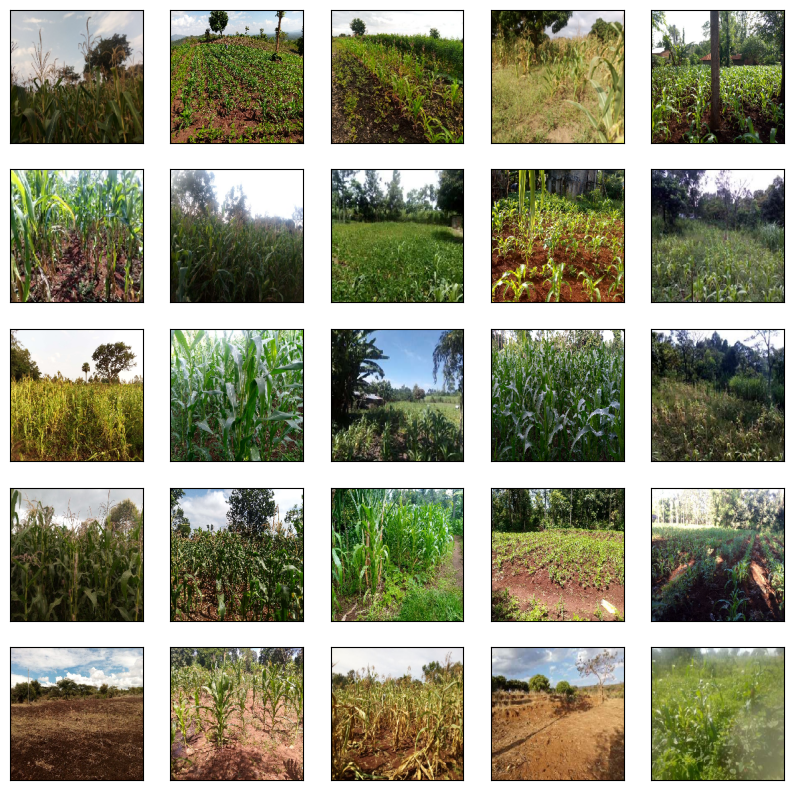

In [9]:
plt.figure(figsize = (10, 10))
# Select a subset of image files to display
sample_files = random.sample(image_files, min(25, len(image_files)))
for i, file in enumerate(sample_files):
  img_path = os.path.join(image_dir, file)
  img = image.load_img(img_path, target_size = (200, 200))  # Adjust the target size as needed
  plt.subplot(5, 5, i + 1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(img)
plt.show()

In [10]:
from PIL import Image
from tqdm import tqdm
import hashlib
import pandas as pd

In [11]:
input_dir = "/content/images/images"

Checking for corrupted images

In [12]:
bad_files = []

# Collect all image file paths
image_files = []
for dirpath, _, filenames in os.walk(image_dir):
    for f in filenames:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(os.path.join(dirpath, f))  # full path!

# Check each image
for path in tqdm(image_files, desc="Checking for corrupted images"):
    try:
        with Image.open(path) as img:
            img.verify()
    except Exception:
        bad_files.append(path)
        try:
            os.remove(path)  # delete corrupted file
        except FileNotFoundError:
            pass  # file already gone

print(f"✅ Removed {len(bad_files)} corrupted images")

Checking for corrupted images: 100%|██████████| 34731/34731 [00:32<00:00, 1062.44it/s]

✅ Removed 0 corrupted images


Checking for duplicates

In [15]:
seen = set()
duplicates = []

for path in tqdm(image_files, desc = "Checking for duplicates"):
    try:
        with open(path, "rb") as f:
            hash_val = hashlib.md5(f.read()).hexdigest()
        if hash_val in seen:
            os.remove(path)
            duplicates.append(path)
        else:
            seen.add(hash_val)
    except Exception as e:
        print(f"❌ Error processing {os.path.basename(path)}: {e}")

print(f"✅ Removed {len(duplicates)} duplicate images")

Checking for duplicates: 100%|██████████| 34731/34731 [01:25<00:00, 407.83it/s]

✅ Removed 0 duplicate images


Removing Outliers

In [16]:
min_size = 50  # min width/height
max_size = 5000  # max width/height

for root, _, files in os.walk(input_dir):
    for file in files:
        path = os.path.join(root, file)
        try:
            img = Image.open(path)
            if img.width < min_size or img.height < min_size or img.width > max_size or img.height > max_size:
                os.remove(path)
        except:
            pass

In [ ]:
# pick first 10 image paths
image_files = []
for root, _, files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith((".jpg")):
            image_files.append(os.path.join(root, file))

In [ ]:
# check sizes
for img_path in image_files:
    with Image.open(img_path) as img:
        print(f"{os.path.basename(img_path)} → {img.size}")  # (width, height)


In [17]:
# Target Size
size = (300, 300)

In [18]:
for img_path in tqdm(image_files, desc = "Resizing images"):
    try:
        with Image.open(img_path).convert("RGB") as img:
            img = img.resize(size, Image.Resampling.LANCZOS)
            img.save(img_path, "JPEG")
    except Exception as e:
        print(f"❌ Error processing {os.path.basename(img_path)}: {e}")

Resizing images: 100%|██████████| 34731/34731 [24:39<00:00, 23.48it/s]


In [ ]:
image_files = []
for root, _, files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith((".jpg")):
            image_files.append(os.path.join(root, file))

In [ ]:
# check sizes
for img_path in image_files:
    with Image.open(img_path) as img:
        print(f"{os.path.basename(img_path)} → {img.size}")  # (width, height)


Preparation Toward Model training

In [19]:
train = pd.read_csv("Train.csv")

In [20]:
train.head()

,ID,damage,filename
0,ID_UBHORS,WD,d036341be8d6cd59851cb80bcc9a70cc9fbdba30.jpg
1,ID_9DSOLZ,G,9ea16180c50d0cd539897eefbfe585314e50a56b.jpg
2,ID_JHLM0G,G,b6b564844041bc68774a553eaf43d61654657dd9.jpg
3,ID_ATREIJ,DR,62262859f0cd411aaf484082ed3ef0b625bc452a.jpg
4,ID_L2GAD6,G,03b6e2a8ace7cb611eccba289f3c83d9bd497584.jpg


In [21]:
import shutil
from pathlib import Path

Mapping Damage type to images

In [22]:
filename_col = "filename"
damage_col = "damage"

In [23]:
# Go through each row and rename files
renamed_count = 0
for _, row in train.iterrows():
    old_name = str(row[filename_col]).lower()
    damage = str(row[damage_col]).replace(" ", "_").lower()  # safe folder name

    old_path = os.path.join(image_dir, old_name)

    if os.path.exists(old_path):
        # New filename: damageType_index.ext
        ext = os.path.splitext(old_name)[1]  # keep .jpg/.png
        new_name = f"{damage}_{renamed_count}{ext}"
        new_path = os.path.join(image_dir, new_name)

        os.rename(old_path, new_path)
        renamed_count += 1

print(f"✅ Done! Renamed {renamed_count} images in {image_dir}")

✅ Done! Renamed 26068 images in /content/images/images


In [ ]:
print("Sample files:", os.listdir(image_dir)[:10])

Moving Mapped images into a new folder

In [26]:
output_dir = "dataset_split/mapped"

In [27]:
os.makedirs(output_dir, exist_ok = True)

In [28]:
moved_count, missing_count = 0, 0

for idx, row in train.iterrows():
    damage = str(row[damage_col]).replace(" ", "_").lower()
    ext = os.path.splitext(str(row[filename_col]))[1].lower()  # keep .jpg/.png
    new_name = f"{damage}_{idx}{ext}"  # matches renamed format
    src = os.path.join(image_dir, new_name)
    dst = os.path.join(output_dir, new_name)

    if os.path.exists(src):
        shutil.move(src, dst)
        moved_count += 1
    else:
        missing_count += 1

print(f"✅ Done! Moved {moved_count} mapped (renamed) files into {output_dir}")
print(f"⚠️ Missing {missing_count} files (listed in CSV but not found on disk)")

✅ Done! Moved 26068 mapped (renamed) files into dataset_split/mapped
⚠️ Missing 0 files (listed in CSV but not found on disk)


Confiming the total number of images mapped and moved to the new folder

In [ ]:
len(train)

26068

In [29]:
mapped_dir = "/content/dataset_split/mapped"

print("Total mapped files:", sum(len(files) for _, _, files in os.walk(mapped_dir)))

Total mapped files: 26068


In [34]:
print("Sample files:", os.listdir(mapped_dir)[:10])

Sample files: ['wd_20550.jpg', 'dr_12006.jpg', 'g_3464.jpg', 'wd_22227.jpg', 'dr_24225.jpg', 'dr_17289.jpg', 'wd_17544.jpg', 'g_5989.jpg', 'dr_22087.jpg', 'g_21672.jpg']


In [33]:
# def preview_images(start_index, n=6):
#     rows = train.iloc[start_index:start_index+int(n)]

#     fig, axes = plt.subplots(3, 2, figsize=(15, 8))
#     axes = axes.flatten()

#     for ax, (_, row) in zip(axes, rows.iterrows()):
#         fname = str(row[filename_col]).lower()
#         img_path = os.path.join(image_dir, fname)

#         if os.path.exists(img_path):
#             img = mpimg.imread(img_path)
#             ax.imshow(img)
#             ax.axis("off")

#             # ✅ Use the correct damage column here:
#             ax.set_title(f"Damage: {row[damage_col]}", fontsize=10, color = "black")
#         else:
#             ax.axis("off")
#             ax.set_title("⚠️ Not Found", fontsize=10, color="gray")

#     plt.tight_layout()
#     plt.show()

In [44]:
dataset_dir = "/content/dataset_split/mapped"
split_dir = "/content/dataset"

In [45]:
# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

In [37]:
mapped_dir = "/content/dataset_split/mapped"

print("Total mapped files:", sum(len(files) for _, _, files in os.walk(mapped_dir)))

Total mapped files: 26068


In [46]:
os.makedirs(split_dir, exist_ok = True)

In [47]:
import shutil
import random
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [48]:
# Step 1: Collect all files & labels from filenames (they have damage type in the name)
data = []
for f in os.listdir(mapped_dir):
    if f.endswith((".jpg", ".jpeg", ".png")):
        label = f.split("_")[0]  # damage type is before first "_"
        data.append((f, label))

df = pd.DataFrame(data, columns=["filename", "label"])

# Step 2: Split train vs temp (val+test)
train_files, temp_files = train_test_split(df, train_size = train_ratio, stratify  = df["label"], random_state = 42)

# Step 3: Split temp into val and test
relative_val_size = val_ratio / (1 - train_ratio)  # adjust ratio
val_files, test_files = train_test_split(temp_files, train_size = relative_val_size, stratify = temp_files["label"], random_state = 42)

splits = {
    "train": train_files,
    "val": val_files,
    "test": test_files
}

# Step 4: Move files into split folders
for split_name, split_df in splits.items():
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Moving {split_name} images"):
        label = row["label"]
        fname = row["filename"]

        src = os.path.join(mapped_dir, fname)
        dst_dir = os.path.join(split_dir, split_name, label)
        os.makedirs(dst_dir, exist_ok = True)
        dst = os.path.join(dst_dir, fname)

        if os.path.exists(src):
            shutil.move(src, dst)

print("✅ Dataset split completed!")
print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

Moving test images: 100%|██████████| 3911/3911 [00:00<00:00, 7902.32it/s]

✅ Dataset split completed!
Train: 18247 | Val: 3910 | Test: 3911


In [49]:
train_dir = "/content/dataset/train"
val_dir = "/content/dataset/val"
test_dir = "/content/dataset/test"
print("Total mapped files:", sum(len(files) for _, _, files in os.walk(train_dir)))
print("Total mapped files:", sum(len(files) for _, _, files in os.walk(val_dir)))
print("Total mapped files:", sum(len(files) for _, _, files in os.walk(test_dir)))

Total mapped files: 18247
Total mapped files: 3910
Total mapped files: 3911


Normalize Pixel Values

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255)
val_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

Data Augmentation on the train

In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range = 20,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode = "nearest"
)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

Building CNN model using 5 classes

In [ ]:
num_classes = 5

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation = "relu", input_shape  = (200, 200, 3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation = "relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation = "relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation = "relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation = "softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compiling Model Using Adam

In [ ]:
model.compile(optimizer = "adam",
              loss = "categorical_crossentropy",
              metrics =["accuracy"])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,761,157 (33.42 MB)

 Trainable params: 8,761,157 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

Model Fitting

In [ ]:
train_generator = train_datagen.flow_from_directory(
    "dataset/train",
    target_size = (200, 200),
    batch_size = 32,
    class_mode = "categorical"
)

val_generator = val_datagen.flow_from_directory(
    "dataset/val",
    target_size = (200, 200),
    batch_size = 32,
    class_mode = "categorical"
)

Found 18247 images belonging to 26073 classes.
Found 3910 images belonging to 26073 classes.


In [ ]:
history = model.fit(train_generator,
                    epochs = 20,
                    validation_data = val_generator)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 26073), output.shape=(None, 5)